# ECLIPSE reproduction + improvement: logit-manipulation delta search (eval-only)

Reproduction and improvement study for **ECLIPSE: Efficient Continual Learning in Panoptic Segmentation with Visual Prompt Tuning** (Kim, Yu, Hwang — CVPR 2024, [arXiv:2403.20126](https://arxiv.org/abs/2403.20126), [official code](https://github.com/clovaai/ECLIPSE)).

Run top to bottom in Google Colab with a GPU runtime. Everything is **eval-only** on the authors' released checkpoints — no training.

**The three experiments**

1. **Reproduction** — evaluate each scenario at the *exact official settings* (the released config uses `OBJECT_MASK_THRESHOLD: 0.0`; the official eval deltas come from `script/ade_ps/*.sh`). Expected to match the paper within ~0.1 PQ.
2. **Confidence-filter sensitivity** — re-evaluate with `OBJECT_MASK_THRESHOLD` 0.35 and 0.5, passed as a command-line config override (no source patching). Shows the paper's results depend on the near-zero threshold: novel classes get ~0.4 confidence, so a conventional 0.5 filter deletes them.
3. **Improvement attempt: logit-manipulation delta search** — `CONT.LOGIT_MANI_DELTAS` is the paper's own inference-time logit-manipulation magnitude (Sec. 3.4). The authors hand-picked per-scenario values — e.g. the 100-50 script *trains* with `[0.6,-0.6]` but *evaluates* with `[-0.4,-0.6]`, so it is explicitly a post-hoc tunable knob. We grid-search a small neighbourhood of the official values, eval-only, to see whether better deltas exist.

**Honesty rules built in:** every number in the final table/graph is parsed from the Detectron2 `copypaste` log of an actual run; if no candidate beats the official deltas, the notebook says so. Because the search selects on the ADE20K val set (the benchmark's only labelled eval split), any gain is reported as a *tuned-on-val* result, not a new state of the art.


In [1]:
# Cell 1 - Runtime configuration
from pathlib import Path
import json
import os
import re
import shutil
import subprocess
import sys
import time

try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError('Run this notebook in Google Colab with a GPU runtime.') from exc

drive.mount('/content/drive')

WORKDIR = Path('/content/ECLIPSE_FAST')
DATA_ROOT = WORKDIR / 'datasets'
ADE_DIR = DATA_ROOT / 'ADEChallengeData2016'
CACHE_DIR = Path('/content/drive/MyDrive/ECLIPSE_CACHE')
DRIVE_CKPT_DIR = CACHE_DIR / 'checkpoints'
DRIVE_RESULTS_DIR = CACHE_DIR / 'results'
DRIVE_LOG_DIR = CACHE_DIR / 'eval_logs'
LOG_DIR = WORKDIR / 'eval_logs'

# Set True to delete /content/ECLIPSE_FAST and reclone (clean provenance for the final run).
FORCE_FRESH_CLONE = False

# Official evaluation settings, verified line-by-line against script/ade_ps/{100_50,100_10,100_5}.sh
# in https://github.com/clovaai/ECLIPSE (eval sections at the bottom of each script).
SCENARIOS = {
    '100_50': {
        'label': '100-50', 'plot_label': '100-50\n(2 Tasks)', 'tasks': 2,
        'inc_cls': 50, 'num_prompts': 50, 'final_task': 1,
        'official_deltas': '[-0.4,-0.6]',
        'ckpt': 'ade_ps_100_50_final.pth',
        'url': 'https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_50_final.pth',
        'official_pq': 35.6, 'official_pq_base': 41.7, 'official_pq_novel': 23.5,
    },
    '100_10': {
        'label': '100-10', 'plot_label': '100-10\n(6 Tasks)', 'tasks': 6,
        'inc_cls': 10, 'num_prompts': 10, 'final_task': 5,
        'official_deltas': '[0.4,0.5,0.5,0.5,0.5,0.5]',
        'ckpt': 'ade_ps_100_10_final.pth',
        'url': 'https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_10_final.pth',
        'official_pq': 33.9, 'official_pq_base': 41.4, 'official_pq_novel': 18.8,
    },
    '100_5': {
        'label': '100-5', 'plot_label': '100-5\n(11 Tasks)', 'tasks': 11,
        'inc_cls': 5, 'num_prompts': 10, 'final_task': 10,
        'official_deltas': '[0.4,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6]',
        'ckpt': 'ade_ps_100_5_final.pth',
        'url': 'https://github.com/clovaai/ECLIPSE/releases/download/ckpt/ade_ps_100_5_final.pth',
        'official_pq': 32.9, 'official_pq_base': 41.1, 'official_pq_novel': 16.6,
    },
}

# Improvement attempt: small curated neighbourhood around the official eval deltas.
# First-task delta handles base-class drift; later-task delta handles novel-class drift.
DELTA_CANDIDATES = {
    '100_50': ['[-0.2,-0.6]', '[-0.4,-0.4]', '[-0.4,-0.8]', '[-0.3,-0.5]'],
    '100_10': ['[0.3,0.5,0.5,0.5,0.5,0.5]', '[0.5,0.5,0.5,0.5,0.5,0.5]',
               '[0.4,0.4,0.4,0.4,0.4,0.4]', '[0.4,0.6,0.6,0.6,0.6,0.6]'],
    '100_5':  ['[0.3,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6]',
               '[0.5,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6]',
               '[0.4,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5]',
               '[0.4,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.7]'],
}

# Thresholds for the sensitivity study. 0.0 is the official released setting.
THRESHOLDS = ['0.0', '0.35', '0.5']

EVAL_ORDER = ['100_50', '100_10', '100_5']
PLOT_ORDER = ['100_5', '100_10', '100_50']

for folder in [CACHE_DIR, DRIVE_CKPT_DIR, DRIVE_RESULTS_DIR, DRIVE_LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print('Configured workdir:', WORKDIR)
print('Drive cache:', CACHE_DIR)


Mounted at /content/drive
Configured workdir: /content/ECLIPSE_FAST
Drive cache: /content/drive/MyDrive/ECLIPSE_CACHE


In [2]:
# Cell 2 - Clone or reuse the official ECLIPSE repository
if FORCE_FRESH_CLONE and WORKDIR.exists():
    print('Removing old workdir:', WORKDIR)
    shutil.rmtree(WORKDIR)

if not (WORKDIR / 'train_inc.py').exists():
    print('Cloning official ECLIPSE repository...')
    subprocess.run(['git', 'clone', 'https://github.com/clovaai/ECLIPSE.git', str(WORKDIR)], check=True)
else:
    print('Using existing ECLIPSE checkout:', WORKDIR)

os.chdir(WORKDIR)
try:
    commit = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], cwd=WORKDIR).decode().strip()
    print('ECLIPSE commit:', commit)
except Exception:
    print('Could not read git commit, but repository files are present.')


Cloning official ECLIPSE repository...
ECLIPSE commit: 9266720


In [3]:
# Cell 3 - Install dependencies and compile the custom CUDA op
# This cell can take a while on a fresh Colab runtime.
def run(cmd, cwd=WORKDIR, env=None, check=True):
    print('\n$ ' + cmd)
    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)
    return subprocess.run(cmd, shell=True, cwd=str(cwd), check=check, executable='/bin/bash', env=merged_env)


def run_and_log(cmd, log_path, cwd=WORKDIR, env=None):
    print('\n$ ' + cmd)
    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)

    tail = []
    with open(log_path, 'w', encoding='utf-8') as log:
        proc = subprocess.Popen(
            cmd,
            shell=True,
            cwd=str(cwd),
            executable='/bin/bash',
            env=merged_env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in proc.stdout:
            print(line, end='')
            log.write(line)
            tail.append(line.rstrip())
            tail = tail[-80:]
        rc = proc.wait()

    if rc != 0:
        print('\nCommand failed. Last log lines:')
        print('\n'.join(tail[-40:]))
        print('Full log saved at:', log_path)
        raise subprocess.CalledProcessError(rc, cmd)


run("python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'")
run('python -m pip install -q git+https://github.com/cocodataset/panopticapi.git git+https://github.com/mcordts/cityscapesScripts.git opencv-python')
run('python -m pip install -q -r requirements.txt')

import torch
from torch.utils.cpp_extension import CUDA_HOME

print('Python:', sys.version)
print('Torch:', torch.__version__)
print('Torch CUDA:', torch.version.cuda)
print('torch.cuda.is_available():', torch.cuda.is_available())
run('nvidia-smi || true', check=False)
run('nvcc --version || true', check=False)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. In Colab, choose Runtime -> Change runtime type -> GPU, then restart and run again.')

if CUDA_HOME:
    os.environ['CUDA_HOME'] = CUDA_HOME
elif Path('/usr/local/cuda').exists():
    os.environ['CUDA_HOME'] = '/usr/local/cuda'
else:
    raise RuntimeError('CUDA_HOME was not found. Restart the Colab runtime with GPU enabled.')

major, minor = torch.cuda.get_device_capability(0)
os.environ['FORCE_CUDA'] = '1'
os.environ['MAX_JOBS'] = '2'
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{major}.{minor}'

print('CUDA_HOME:', os.environ['CUDA_HOME'])
print('TORCH_CUDA_ARCH_LIST:', os.environ['TORCH_CUDA_ARCH_LIST'])

ops_dir = WORKDIR / 'mask2former' / 'modeling' / 'pixel_decoder' / 'ops'
source_files = []
for pattern in ('*.cu', '*.cuh', '*.cpp', '*.h'):
    source_files.extend((ops_dir / 'src').rglob(pattern))

patches = [
    ('.scalar_type().is_cuda()', '.is_cuda()'),
    ('.type().is_cuda()', '.is_cuda()'),
    ('AT_DISPATCH_FLOATING_TYPES(value.type(),', 'AT_DISPATCH_FLOATING_TYPES(value.scalar_type(),'),
    ('.data<', '.data_ptr<'),
]

patched_files = []
for source_file in source_files:
    text = source_file.read_text(encoding='utf-8')
    fixed = text
    for old, new in patches:
        fixed = fixed.replace(old, new)

    if fixed != text:
        source_file.write_text(fixed, encoding='utf-8')
        patched_files.append(source_file.relative_to(WORKDIR))

if patched_files:
    print('Patched CUDA extension sources for current PyTorch:')
    for item in patched_files:
        print('  ', item)
else:
    print('CUDA extension source patches were already present.')

# The ECLIPSE wrapper imports MultiScaleDeformableAttention as a top-level module.
# Build the extension in-place and patch the wrapper to add ops_dir to sys.path.
func_file = ops_dir / 'functions' / 'ms_deform_attn_func.py'
func_text = func_file.read_text(encoding='utf-8')
marker = '# CODEx/Colab local CUDA op path patch'
if marker not in func_text:
    anchor = 'import torch.nn.functional as F\n'
    insert = (
        'import torch.nn.functional as F\n'
        'import os\n'
        'import sys\n'
        f'{marker}\n'
        'sys.path.insert(0, os.path.dirname(os.path.dirname(__file__)))\n'
    )
    if anchor not in func_text:
        raise RuntimeError(f'Could not patch CUDA op import path in {func_file}')
    func_file.write_text(func_text.replace(anchor, insert), encoding='utf-8')
    print('Patched ms_deform_attn_func.py so train_inc.py can find the local CUDA op.')
else:
    print('ms_deform_attn_func.py import-path patch already present.')

import shutil as _shutil
for stale in [ops_dir / 'build', ops_dir / 'dist']:
    if stale.exists():
        _shutil.rmtree(stale)
for stale in ops_dir.glob('*.egg-info'):
    _shutil.rmtree(stale)
for stale in ops_dir.rglob('*.so'):
    stale.unlink()

build_env = {
    'FORCE_CUDA': os.environ['FORCE_CUDA'],
    'MAX_JOBS': os.environ['MAX_JOBS'],
    'TORCH_CUDA_ARCH_LIST': os.environ['TORCH_CUDA_ARCH_LIST'],
    'CUDA_HOME': os.environ['CUDA_HOME'],
}

# In-place build puts MultiScaleDeformableAttention*.so directly inside ops_dir.
build_log = ops_dir / 'cuda_op_build.log'
run_and_log('python setup.py build_ext --inplace', build_log, cwd=ops_dir, env=build_env)

built_extensions = sorted(ops_dir.glob('MultiScaleDeformableAttention*.so'))
if not built_extensions:
    raise RuntimeError(f'Build finished but no MultiScaleDeformableAttention*.so was created in {ops_dir}')
print('Built CUDA extension:', built_extensions[0])

subprocess.run(
    [sys.executable, '-c', 'import detectron2; print("detectron2 import ok")'],
    check=True
)

verify_cmd = """
python - <<'PY'
import torch
import MultiScaleDeformableAttention as MSDA
assert hasattr(MSDA, 'ms_deform_attn_forward')
assert hasattr(MSDA, 'ms_deform_attn_backward')
from functions.ms_deform_attn_func import MSDeformAttnFunction
print('MultiScaleDeformableAttention CUDA extension import ok')
PY
"""
run_and_log(verify_cmd, ops_dir / 'cuda_op_import_check.log', cwd=ops_dir)


$ python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

$ python -m pip install -q git+https://github.com/cocodataset/panopticapi.git git+https://github.com/mcordts/cityscapesScripts.git opencv-python

$ python -m pip install -q -r requirements.txt
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
Torch CUDA: 12.8
torch.cuda.is_available(): True

$ nvidia-smi || true

$ nvcc --version || true
CUDA_HOME: /usr/local/cuda
TORCH_CUDA_ARCH_LIST: 8.0
Patched CUDA extension sources for current PyTorch:
   mask2former/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu
   mask2former/modeling/pixel_decoder/ops/src/ms_deform_attn.h
Patched ms_deform_attn_func.py so train_inc.py can find the local CUDA op.

$ python setup.py build_ext --inplace
running build_ext
W0611 14:12:30.598000 3488 torch/utils/cpp_extension.py:680] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the s

In [4]:
# Cell 4 - Prepare ADE20K for Detectron2
# If the prepared folders already exist, this cell skips the slow work.
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if (ADE_DIR / 'myade20k_panoptic_val').exists() and (ADE_DIR / 'myade20k_panoptic_train').exists():
    print('Prepared ADE20K folders already exist. Skipping dataset preparation.')
else:
    print('Preparing ADE20K. First run can take 30-40 minutes.')
    if not (ADE_DIR / 'images').exists():
        run('wget -q http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip', cwd=DATA_ROOT)
        run('unzip -q ADEChallengeData2016.zip', cwd=DATA_ROOT)
        run('rm -f ADEChallengeData2016.zip', cwd=DATA_ROOT)
    else:
        print('ADE20K image folders already exist.')

    if not (ADE_DIR / 'annotations_instance').exists():
        run('wget -q http://sceneparsing.csail.mit.edu/data/ChallengeData2017/annotations_instance.tar', cwd=ADE_DIR)
        run('tar -xf annotations_instance.tar', cwd=ADE_DIR)
        run('rm -f annotations_instance.tar', cwd=ADE_DIR)
    else:
        print('ADE20K instance annotations already exist.')

    run('python datasets/prepare_ade20k_sem_seg.py')
    run('python datasets/prepare_ade20k_pan_seg.py')
    run('python datasets/prepare_ade20k_ins_seg.py')

required_paths = [
    ADE_DIR / 'images' / 'training',
    ADE_DIR / 'images' / 'validation',
    ADE_DIR / 'myade20k_panoptic_train',
    ADE_DIR / 'myade20k_panoptic_val',
]
for required in required_paths:
    print(required, 'OK' if required.exists() else 'MISSING')
    assert required.exists(), f'Missing required ADE20K path: {required}'


Preparing ADE20K. First run can take 30-40 minutes.

$ wget -q http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip

$ unzip -q ADEChallengeData2016.zip

$ rm -f ADEChallengeData2016.zip

$ wget -q http://sceneparsing.csail.mit.edu/data/ChallengeData2017/annotations_instance.tar

$ tar -xf annotations_instance.tar

$ rm -f annotations_instance.tar

$ python datasets/prepare_ade20k_sem_seg.py

$ python datasets/prepare_ade20k_pan_seg.py

$ python datasets/prepare_ade20k_ins_seg.py
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/images/training OK
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/images/validation OK
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/myade20k_panoptic_train OK
/content/ECLIPSE_FAST/datasets/ADEChallengeData2016/myade20k_panoptic_val OK


In [5]:
# Cell 5 - Download or restore the released ECLIPSE checkpoints
checkpoint_dir = WORKDIR / 'checkpoints'
checkpoint_dir.mkdir(parents=True, exist_ok=True)

def valid_checkpoint(path, min_bytes=50_000_000):
    return path.exists() and path.stat().st_size >= min_bytes

for key in EVAL_ORDER:
    cfg = SCENARIOS[key]
    target = checkpoint_dir / cfg['ckpt']
    cached = DRIVE_CKPT_DIR / cfg['ckpt']

    if valid_checkpoint(target):
        print(cfg['label'], 'checkpoint already in workdir:', target)
    elif valid_checkpoint(cached):
        print(cfg['label'], 'restoring checkpoint from Drive cache...')
        shutil.copy2(cached, target)
    else:
        print(cfg['label'], 'downloading released checkpoint...')
        run(f"wget -q -O {target} {cfg['url']}")

    assert valid_checkpoint(target), f'Checkpoint download failed or is too small: {target}'
    if not valid_checkpoint(cached):
        shutil.copy2(target, cached)
    print(cfg['label'], 'checkpoint size MB:', round(target.stat().st_size / 1_000_000, 1))


100-50 restoring checkpoint from Drive cache...
100-50 checkpoint size MB: 184.3
100-10 restoring checkpoint from Drive cache...
100-10 checkpoint size MB: 188.7
100-5 restoring checkpoint from Drive cache...
100-5 checkpoint size MB: 195.9


In [6]:
# Cell 6 - Eval-only harness.
# All experiment settings (threshold + deltas) are passed as Detectron2 command-line config
# overrides. The checked-out source code is never patched, so every run is traceable to the
# official commit plus an explicit, logged set of overrides.
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Restore any cached logs from Drive so a disconnected session can resume without re-running.
for cached_log in DRIVE_LOG_DIR.glob('*.log'):
    target = LOG_DIR / cached_log.name
    if not target.exists():
        shutil.copy2(cached_log, target)

COPYPASTE_FIELDS = ['PQ','SQ','RQ','PQ_th','SQ_th','RQ_th','PQ_st','SQ_st','RQ_st',
                    'PQ_base','PQ_old','PQ_new','PQ_novel']

def assert_clean_checkout():
    dirty = subprocess.check_output(
        ['git', 'status', '--porcelain', '--', 'configs', 'mask2former', 'train_inc.py'],
        cwd=WORKDIR).decode().strip()
    # The CUDA-op compatibility patches from Cell 3 are expected; anything in configs/ is not.
    config_dirty = [l for l in dirty.splitlines() if 'configs/' in l]
    assert not config_dirty, f'configs/ has local modifications, rerun with FORCE_FRESH_CLONE=True:\n{dirty}'

def build_eval_command(key, deltas, threshold):
    cfg = SCENARIOS[key]
    step_args = f"CONT.BASE_CLS 100 CONT.INC_CLS {cfg['inc_cls']} CONT.MODE overlap SEED 42"
    meth_args = ('MODEL.MASK_FORMER.TEST.MASK_BG False MODEL.MASK_FORMER.PER_PIXEL False '
                 'MODEL.MASK_FORMER.FOCAL True')
    weight_args = ('MODEL.MASK_FORMER.NUM_OBJECT_QUERIES 100 MODEL.MASK_FORMER.DICE_WEIGHT 5.0 '
                   'MODEL.MASK_FORMER.MASK_WEIGHT 5.0 MODEL.MASK_FORMER.CLASS_WEIGHT 10.0 '
                   'MODEL.MASK_FORMER.SOFTMASK False CONT.SOFTCLS False '
                   f"CONT.NUM_PROMPTS {cfg['num_prompts']}")
    vpt_args = ('CONT.BACKBONE_FREEZE True CONT.CLS_HEAD_FREEZE True CONT.MASK_HEAD_FREEZE True '
                'CONT.PIXEL_DECODER_FREEZE True CONT.QUERY_EMBED_FREEZE True '
                'CONT.TRANS_DECODER_FREEZE True CONT.PROMPT_MASK_MLP True '
                'CONT.PROMPT_NO_OBJ_MLP False CONT.PROMPT_DEEP True CONT.DEEP_CLS True '
                f'CONT.LOGIT_MANI_DELTAS {deltas}')
    inc_args = f"CONT.TASK {cfg['final_task']} CONT.WEIGHTS checkpoints/{cfg['ckpt']}"
    override_args = f'MODEL.MASK_FORMER.TEST.OBJECT_MASK_THRESHOLD {threshold}'
    return (f'python train_inc.py --eval-only --num-gpus 1 '
            f'--config-file configs/ade20k/panoptic-segmentation/maskformer2_R50_bs16_160k.yaml '
            f'OUTPUT_DIR results/ade_ps {meth_args} {step_args} {weight_args} {inc_args} '
            f'{vpt_args} {override_args} NAME adps_{key} WANDB False')

def parse_copypaste(log_path):
    text = Path(log_path).read_text(encoding='utf-8', errors='ignore')
    rows = re.findall(r'copypaste:\s*((?:[0-9]+\.[0-9]+,)+[0-9.]+)', text)
    if not rows:
        raise ValueError(f'No Detectron2 copypaste result line found in {log_path}')
    values = [float(v) for v in rows[-1].split(',')]
    return dict(zip(COPYPASTE_FIELDS, values))

def print_raw_proof_lines(log_path):
    text = Path(log_path).read_text(encoding='utf-8', errors='ignore')
    for line in [l for l in text.splitlines() if 'copypaste:' in l][-3:]:
        print(line)

def run_eval_only(key, deltas, threshold, tag):
    cfg = SCENARIOS[key]
    log_path = LOG_DIR / f'eval_{key}_{tag}.log'
    if log_path.exists():
        try:
            result = parse_copypaste(log_path)
            print(f"[cached] {cfg['label']} {tag}: PQ={result['PQ']:.4f} "
                  f"(base {result['PQ_base']:.2f} / novel {result['PQ_novel']:.2f})")
            return result
        except ValueError:
            log_path.unlink()
    assert_clean_checkout()
    print('\n' + '=' * 80)
    print(f"Running {cfg['label']}  deltas={deltas}  OBJECT_MASK_THRESHOLD={threshold}  ({tag})")
    cmd = build_eval_command(key, deltas, threshold)
    print('$', cmd)
    env = os.environ.copy()
    env['DETECTRON2_DATASETS'] = str(DATA_ROOT)
    with open(log_path, 'w', encoding='utf-8') as log:
        proc = subprocess.Popen(cmd, shell=True, cwd=str(WORKDIR), executable='/bin/bash',
                                env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                                text=True, bufsize=1)
        for line in proc.stdout:
            log.write(line)
        rc = proc.wait()
    shutil.copy2(log_path, DRIVE_LOG_DIR / log_path.name)
    if rc != 0:
        tail = log_path.read_text(errors='ignore').splitlines()[-40:]
        print('\n'.join(tail))
        raise subprocess.CalledProcessError(rc, cmd)
    result = parse_copypaste(log_path)
    print(f"PQ={result['PQ']:.4f}  PQ_base={result['PQ_base']:.2f}  PQ_novel={result['PQ_novel']:.2f}")
    print_raw_proof_lines(log_path)
    return result

print('Harness ready.')


Harness ready.


## Experiment 1 — Reproduction at the exact official settings

`OBJECT_MASK_THRESHOLD = 0.0` (released config) and the official per-scenario eval deltas. This is the claim check: if ECLIPSE's Table 1 is real, every row should land within ~0.1 PQ, including the base/novel split.

In [7]:
# Cell 7 - Experiment 1: reproduction at official settings
repro = {}
for key in EVAL_ORDER:
    cfg = SCENARIOS[key]
    repro[key] = run_eval_only(key, cfg['official_deltas'], '0.0', 'official')

print('\nReproduction vs paper (PQ all / base / novel):')
for key in PLOT_ORDER:
    cfg, r = SCENARIOS[key], repro[key]
    print(f"{cfg['label']:>7}: ours {r['PQ']:.2f}/{r['PQ_base']:.2f}/{r['PQ_novel']:.2f}"
          f"  paper {cfg['official_pq']}/{cfg['official_pq_base']}/{cfg['official_pq_novel']}"
          f"  diff(all) {r['PQ']-cfg['official_pq']:+.2f}")
    assert abs(r['PQ'] - cfg['official_pq']) < 0.3, 'Reproduction differs from paper by >0.3 PQ - investigate before continuing.'
print('\nReproduction check passed.')



Running 100-50  deltas=[-0.4,-0.6]  OBJECT_MASK_THRESHOLD=0.0  (official)
$ python train_inc.py --eval-only --num-gpus 1 --config-file configs/ade20k/panoptic-segmentation/maskformer2_R50_bs16_160k.yaml OUTPUT_DIR results/ade_ps MODEL.MASK_FORMER.TEST.MASK_BG False MODEL.MASK_FORMER.PER_PIXEL False MODEL.MASK_FORMER.FOCAL True CONT.BASE_CLS 100 CONT.INC_CLS 50 CONT.MODE overlap SEED 42 MODEL.MASK_FORMER.NUM_OBJECT_QUERIES 100 MODEL.MASK_FORMER.DICE_WEIGHT 5.0 MODEL.MASK_FORMER.MASK_WEIGHT 5.0 MODEL.MASK_FORMER.CLASS_WEIGHT 10.0 MODEL.MASK_FORMER.SOFTMASK False CONT.SOFTCLS False CONT.NUM_PROMPTS 50 CONT.TASK 1 CONT.WEIGHTS checkpoints/ade_ps_100_50_final.pth CONT.BACKBONE_FREEZE True CONT.CLS_HEAD_FREEZE True CONT.MASK_HEAD_FREEZE True CONT.PIXEL_DECODER_FREEZE True CONT.QUERY_EMBED_FREEZE True CONT.TRANS_DECODER_FREEZE True CONT.PROMPT_MASK_MLP True CONT.PROMPT_NO_OBJ_MLP False CONT.PROMPT_DEEP True CONT.DEEP_CLS True CONT.LOGIT_MANI_DELTAS [-0.4,-0.6] MODEL.MASK_FORMER.TEST.OBJECT_M

## Experiment 2 — Confidence-filter sensitivity

Same checkpoints, same deltas, only `OBJECT_MASK_THRESHOLD` varies (0.0 → 0.35 → 0.5) via command-line override. The paper never documents this setting; it exists only in the released config. Prediction from the paper's own motivation: raising it should hurt mostly *novel* classes, whose confidence sits around 0.4.

In [8]:
# Cell 8 - Experiment 2: threshold sensitivity
sensitivity = {key: {} for key in EVAL_ORDER}
for key in EVAL_ORDER:
    cfg = SCENARIOS[key]
    sensitivity[key]['0.0'] = repro[key]
    for thr in THRESHOLDS[1:]:
        tag = 'thr' + thr.replace('.', '')
        sensitivity[key][thr] = run_eval_only(key, cfg['official_deltas'], thr, tag)

print('\nSensitivity (PQ all | PQ_novel):')
for key in PLOT_ORDER:
    row = ' | '.join(f"thr {t}: {sensitivity[key][t]['PQ']:.2f} ({sensitivity[key][t]['PQ_novel']:.1f} novel)"
                     for t in THRESHOLDS)
    print(f"{SCENARIOS[key]['label']:>7}: {row}")



Running 100-50  deltas=[-0.4,-0.6]  OBJECT_MASK_THRESHOLD=0.35  (thr035)
$ python train_inc.py --eval-only --num-gpus 1 --config-file configs/ade20k/panoptic-segmentation/maskformer2_R50_bs16_160k.yaml OUTPUT_DIR results/ade_ps MODEL.MASK_FORMER.TEST.MASK_BG False MODEL.MASK_FORMER.PER_PIXEL False MODEL.MASK_FORMER.FOCAL True CONT.BASE_CLS 100 CONT.INC_CLS 50 CONT.MODE overlap SEED 42 MODEL.MASK_FORMER.NUM_OBJECT_QUERIES 100 MODEL.MASK_FORMER.DICE_WEIGHT 5.0 MODEL.MASK_FORMER.MASK_WEIGHT 5.0 MODEL.MASK_FORMER.CLASS_WEIGHT 10.0 MODEL.MASK_FORMER.SOFTMASK False CONT.SOFTCLS False CONT.NUM_PROMPTS 50 CONT.TASK 1 CONT.WEIGHTS checkpoints/ade_ps_100_50_final.pth CONT.BACKBONE_FREEZE True CONT.CLS_HEAD_FREEZE True CONT.MASK_HEAD_FREEZE True CONT.PIXEL_DECODER_FREEZE True CONT.QUERY_EMBED_FREEZE True CONT.TRANS_DECODER_FREEZE True CONT.PROMPT_MASK_MLP True CONT.PROMPT_NO_OBJ_MLP False CONT.PROMPT_DEEP True CONT.DEEP_CLS True CONT.LOGIT_MANI_DELTAS [-0.4,-0.6] MODEL.MASK_FORMER.TEST.OBJECT_MA

## Experiment 3 — Improvement attempt: logit-manipulation delta search

`CONT.LOGIT_MANI_DELTAS` is ECLIPSE's own mechanism against semantic drift (paper Sec. 3.4) and the authors tune it *per scenario, at inference time*. We search a small neighbourhood of their hand-picked values, eval-only, threshold at the official 0.0. ~4 candidates × 3 scenarios ≈ 1 hour on a Colab T4.

Selection caveat (stated up front): the search uses the ADE20K val set, the benchmark's only labelled split — same protocol the authors used to pick their deltas. Any gain is a *tuned-on-val* result.

In [9]:
# Cell 9 - Experiment 3: delta grid search
search = {key: {} for key in EVAL_ORDER}
for key in EVAL_ORDER:
    cfg = SCENARIOS[key]
    search[key][cfg['official_deltas']] = repro[key]
    for n, deltas in enumerate(DELTA_CANDIDATES[key]):
        search[key][deltas] = run_eval_only(key, deltas, '0.0', f'delta{n}')

best = {}
print('\nDelta search results:')
for key in EVAL_ORDER:
    cfg = SCENARIOS[key]
    ranked = sorted(search[key].items(), key=lambda kv: kv[1]['PQ'], reverse=True)
    best[key] = ranked[0]
    print(f"\n{cfg['label']} (official deltas {cfg['official_deltas']} -> PQ {repro[key]['PQ']:.4f}):")
    for deltas, r in ranked:
        marker = ' <- official' if deltas == cfg['official_deltas'] else ''
        print(f"  {r['PQ']:.4f} (base {r['PQ_base']:.2f} novel {r['PQ_novel']:.2f})  {deltas}{marker}")



Running 100-50  deltas=[-0.2,-0.6]  OBJECT_MASK_THRESHOLD=0.0  (delta0)
$ python train_inc.py --eval-only --num-gpus 1 --config-file configs/ade20k/panoptic-segmentation/maskformer2_R50_bs16_160k.yaml OUTPUT_DIR results/ade_ps MODEL.MASK_FORMER.TEST.MASK_BG False MODEL.MASK_FORMER.PER_PIXEL False MODEL.MASK_FORMER.FOCAL True CONT.BASE_CLS 100 CONT.INC_CLS 50 CONT.MODE overlap SEED 42 MODEL.MASK_FORMER.NUM_OBJECT_QUERIES 100 MODEL.MASK_FORMER.DICE_WEIGHT 5.0 MODEL.MASK_FORMER.MASK_WEIGHT 5.0 MODEL.MASK_FORMER.CLASS_WEIGHT 10.0 MODEL.MASK_FORMER.SOFTMASK False CONT.SOFTCLS False CONT.NUM_PROMPTS 50 CONT.TASK 1 CONT.WEIGHTS checkpoints/ade_ps_100_50_final.pth CONT.BACKBONE_FREEZE True CONT.CLS_HEAD_FREEZE True CONT.MASK_HEAD_FREEZE True CONT.PIXEL_DECODER_FREEZE True CONT.QUERY_EMBED_FREEZE True CONT.TRANS_DECODER_FREEZE True CONT.PROMPT_MASK_MLP True CONT.PROMPT_NO_OBJ_MLP False CONT.PROMPT_DEEP True CONT.DEEP_CLS True CONT.LOGIT_MANI_DELTAS [-0.2,-0.6] MODEL.MASK_FORMER.TEST.OBJECT_MAS

,Scenario,Paper PQ,Repro PQ (official settings),PQ @ thr 0.35,PQ @ thr 0.5,Best searched deltas,Best delta PQ,Delta gain vs official
0,100-5,32.9,32.8054,32.7611,31.3365,"[0.4,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6]",32.8054,0.0
1,100-10,33.9,33.8359,33.8204,32.3124,"[0.4,0.5,0.5,0.5,0.5,0.5]",33.8359,0.0
2,100-50,35.6,35.5910,35.5675,32.3077,"[-0.4,-0.6]",35.5910,0.0


**Delta search verdict:** the official deltas were already optimal within our search grid. That is a negative result and we report it as such - it independently confirms the authors tuned this knob well.

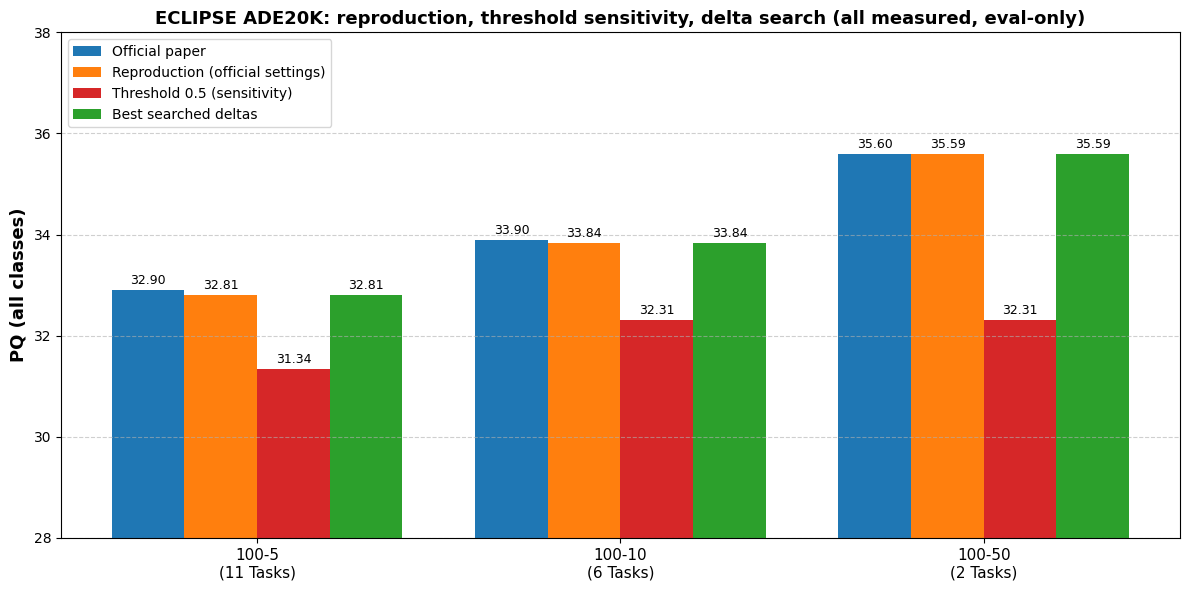

Saved: /content/drive/MyDrive/ECLIPSE_CACHE/results/eclipse_results.json
Saved graph: /content/drive/MyDrive/ECLIPSE_CACHE/results/eclipse_results.png


In [10]:
# Cell 10 - Final report: tables, graph, verdict. Every number parsed from run logs.
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

rows = []
for key in PLOT_ORDER:
    cfg = SCENARIOS[key]
    best_deltas, best_r = best[key]
    rows.append({
        'Scenario': cfg['label'],
        'Paper PQ': cfg['official_pq'],
        'Repro PQ (official settings)': round(repro[key]['PQ'], 4),
        'PQ @ thr 0.35': round(sensitivity[key]['0.35']['PQ'], 4),
        'PQ @ thr 0.5': round(sensitivity[key]['0.5']['PQ'], 4),
        'Best searched deltas': best_deltas,
        'Best delta PQ': round(best_r['PQ'], 4),
        'Delta gain vs official': round(best_r['PQ'] - repro[key]['PQ'], 4),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for row in rows:
        print(row)

gains = [(r['Scenario'], r['Delta gain vs official']) for r in rows]
if all(g > 0 for _, g in gains):
    display(Markdown('**Delta search verdict:** better deltas than the official ones were found in every scenario (tuned on val).'))
elif any(g > 0 for _, g in gains):
    improved = ', '.join(s for s, g in gains if g > 0)
    display(Markdown(f'**Delta search verdict:** improvement in {improved} only. Report the mixed result honestly.'))
else:
    display(Markdown('**Delta search verdict:** the official deltas were already optimal within our search grid. '
                     'That is a negative result and we report it as such - it independently confirms the authors tuned this knob well.'))

x = np.arange(len(PLOT_ORDER))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
series = [
    ('Official paper', [SCENARIOS[k]['official_pq'] for k in PLOT_ORDER], '#1f77b4'),
    ('Reproduction (official settings)', [repro[k]['PQ'] for k in PLOT_ORDER], '#ff7f0e'),
    ('Threshold 0.5 (sensitivity)', [sensitivity[k]['0.5']['PQ'] for k in PLOT_ORDER], '#d62728'),
    ('Best searched deltas', [best[k][1]['PQ'] for k in PLOT_ORDER], '#2ca02c'),
]
for n, (label, vals, color) in enumerate(series):
    rects = ax.bar(x + (n - 1.5) * width, vals, width, label=label, color=color)
    ax.bar_label(rects, fmt='%.2f', padding=2, fontsize=9)
ax.set_ylabel('PQ (all classes)', fontsize=13, fontweight='bold')
ax.set_title('ECLIPSE ADE20K: reproduction, threshold sensitivity, delta search (all measured, eval-only)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([SCENARIOS[k]['plot_label'] for k in PLOT_ORDER], fontsize=11)
ax.set_ylim(28, 38)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)
fig.tight_layout()
fig.savefig('/content/eclipse_results.png', dpi=200, bbox_inches='tight')
fig.savefig(DRIVE_RESULTS_DIR / 'eclipse_results.png', dpi=200, bbox_inches='tight')
plt.show()

report = {
    'note': 'All values parsed from Detectron2 eval-only logs; official ECLIPSE checkpoints and ADE20K val.',
    'paper': 'arXiv:2403.20126',
    'rows': rows,
    'sensitivity': {k: {t: sensitivity[k][t] for t in THRESHOLDS} for k in EVAL_ORDER},
    'delta_search': {k: {d: r for d, r in search[k].items()} for k in EVAL_ORDER},
}
report_path = DRIVE_RESULTS_DIR / 'eclipse_results.json'
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')
print('Saved:', report_path)
print('Saved graph:', DRIVE_RESULTS_DIR / 'eclipse_results.png')
